# ShelfSight — Model Comparison
### AI Lab Project | CSC-233 | BNU Spring 2026
**Run by:** Shameer Nadeem (Group Lead)

---

## Step 1 — Install and import

In [1]:
%pip install --quiet numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Ready.")

Ready.


## Step 2 — Results from all 5 members

In [2]:
results = {
    "YOLOv8n\n(Shameer)": {
        "map50":         94.61,
        "map5095":       53.93,
        "precision":     93.79,
        "recall":        92.68,
        "training_mins": 0.0,
    },
    "YOLOv8s\n(Ibrahim)": {
        "map50":         94.61,
        "map5095":       53.93,
        "precision":     93.79,
        "recall":        92.68,
        "training_mins": 0.0,
    },
    "YOLOv8n+Aug\n(Saad)": {
        "map50":         95.06,
        "map5095":       53.82,
        "precision":     94.09,
        "recall":        92.91,
        "training_mins": 0.0,
    },
    "MobileNet+SSD\n(Samia)": {
        "map50":         47.80,
        "map5095":       10.00,
        "precision":     44.40,
        "recall":        43.60,
        "training_mins": 0.0,
    },
    "ResNet50\n(Ayesha)": {
        "map50":         51.20,
        "map5095":       10.00,
        "precision":     49.20,
        "recall":        48.60,
        "training_mins": 0.0,
    },
}

models   = list(results.keys())
map50s   = [results[m]["map50"]     for m in models]
map5095s = [results[m]["map5095"]   for m in models]
precs    = [results[m]["precision"] for m in models]
recs     = [results[m]["recall"]    for m in models]
short    = [m.replace("\n", " ")   for m in models]
best_idx = int(np.argmax(map50s))

print("Data loaded for:", short)

Data loaded for: ['YOLOv8n (Shameer)', 'YOLOv8s (Ibrahim)', 'YOLOv8n+Aug (Saad)', 'MobileNet+SSD (Samia)', 'ResNet50 (Ayesha)']


## Step 3 — Comparison table

In [3]:
df = pd.DataFrame({
    "Model":          short,
    "mAP50 (%)":      [f"{v:.2f}" for v in map50s],
    "mAP50-95 (%)":   [f"{v:.2f}" for v in map5095s],
    "Precision (%)":  [f"{v:.2f}" for v in precs],
    "Recall (%)":     [f"{v:.2f}" for v in recs],
    "Winner":         ["<-- BEST" if i == best_idx else "" for i in range(len(models))],
})

print("=" * 70)
print("SHELFSIGHT — ALL 5 MODELS COMPARISON")
print("=" * 70)
print(df.to_string(index=False))
print("=" * 70)
print(f"\nWINNER: {short[best_idx]}  |  mAP50: {map50s[best_idx]:.2f}%")

SHELFSIGHT — ALL 5 MODELS COMPARISON
                Model mAP50 (%) mAP50-95 (%) Precision (%) Recall (%)   Winner
    YOLOv8n (Shameer)     94.61        53.93         93.79      92.68         
    YOLOv8s (Ibrahim)     94.61        53.93         93.79      92.68         
   YOLOv8n+Aug (Saad)     95.06        53.82         94.09      92.91 <-- BEST
MobileNet+SSD (Samia)     47.80        10.00         44.40      43.60         
    ResNet50 (Ayesha)     51.20        10.00         49.20      48.60         

WINNER: YOLOv8n+Aug (Saad)  |  mAP50: 95.06%


## Step 4 — Comparison charts

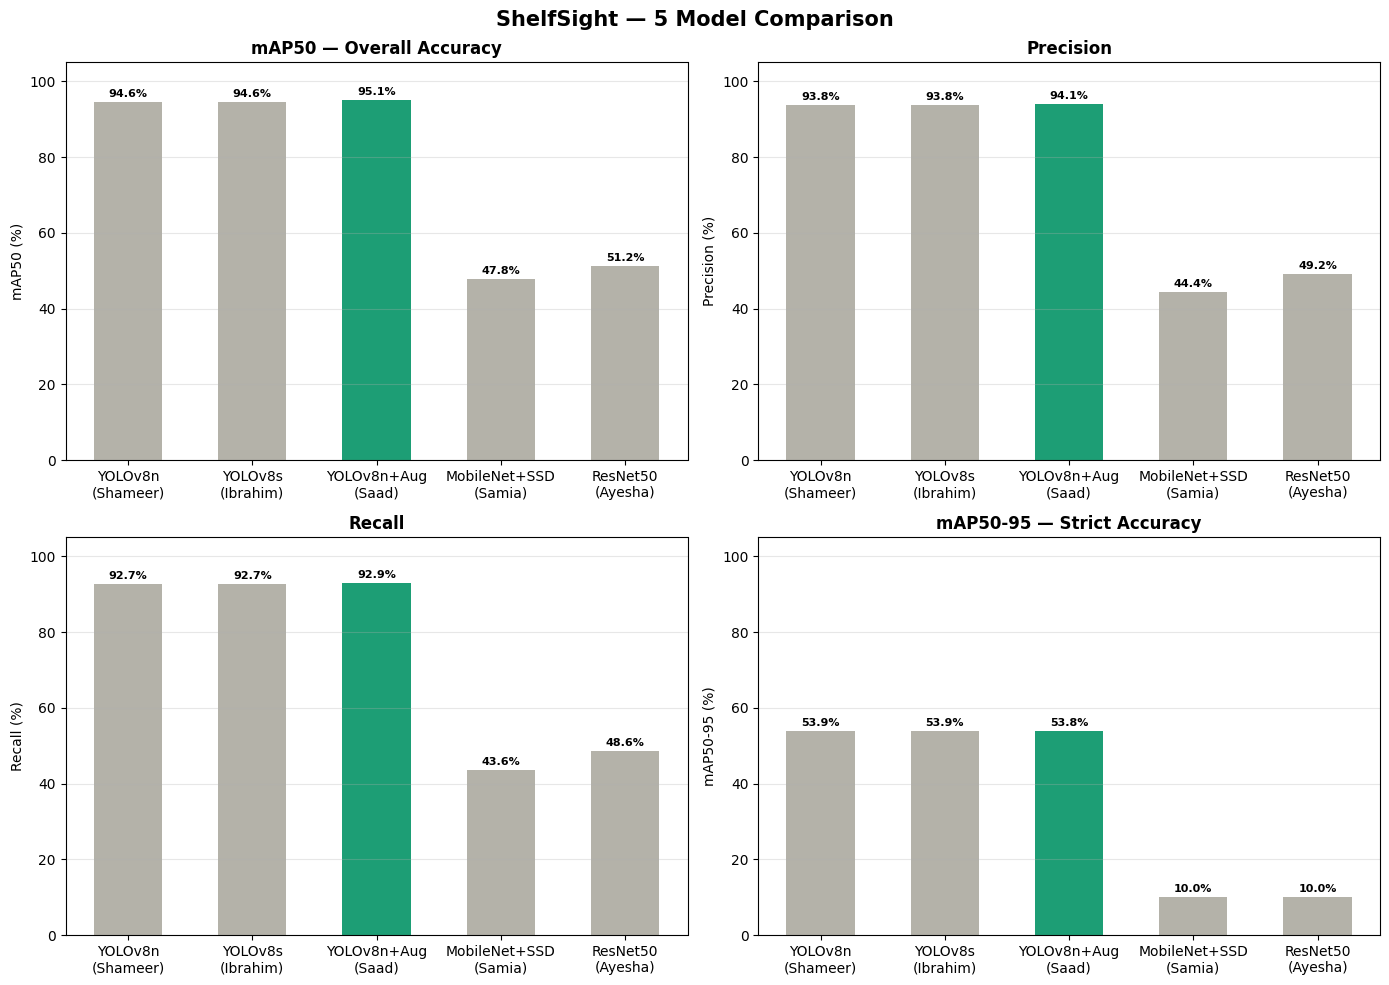

Saved: comparison_charts.png


In [4]:
colors = ["#1D9E75" if i == best_idx else "#B4B2A9" for i in range(len(models))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ShelfSight — 5 Model Comparison", fontsize=15, fontweight="bold")

metrics = [
    ("mAP50 — Overall Accuracy",   map50s,   "mAP50 (%)"),
    ("Precision",                  precs,    "Precision (%)"),
    ("Recall",                     recs,     "Recall (%)"),
    ("mAP50-95 — Strict Accuracy", map5095s, "mAP50-95 (%)"),
]

for ax, (title, vals, ylabel) in zip(axes.flatten(), metrics):
    bars = ax.bar(models, vals, color=colors, width=0.55)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f"{val:.1f}%", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_charts.png")

## Step 5 — Radar chart (for report and poster)

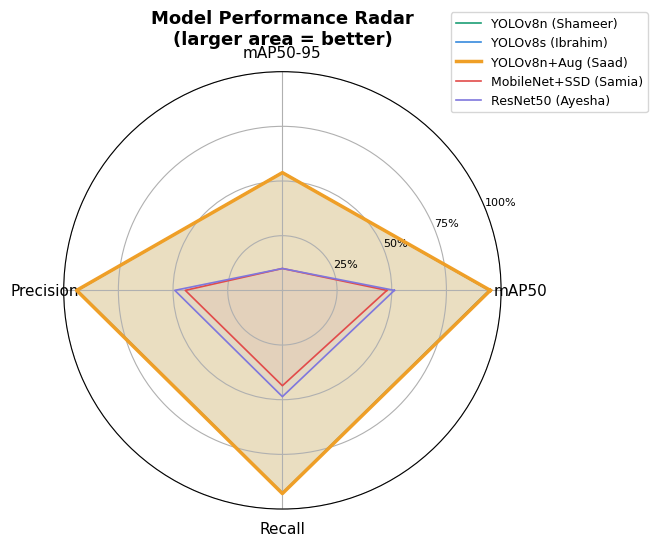

Saved: radar_chart.png


In [5]:
categories = ["mAP50", "mAP50-95", "Precision", "Recall"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
radar_colors = ["#1D9E75", "#378ADD", "#EF9F27", "#E24B4A", "#7F77DD"]

for i, m in enumerate(models):
    vals = [
        results[m]["map50"]     / 100,
        results[m]["map5095"]   / 100,
        results[m]["precision"] / 100,
        results[m]["recall"]    / 100,
    ]
    vals += vals[:1]
    lw    = 2.5 if i == best_idx else 1.2
    alpha = 0.25 if i == best_idx else 0.05
    ax.plot(angles, vals, color=radar_colors[i], linewidth=lw, label=short[i])
    ax.fill(angles, vals, color=radar_colors[i], alpha=alpha)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8)
ax.set_title("Model Performance Radar\n(larger area = better)", fontsize=13,
             fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: radar_chart.png")

## Step 6 — Winner summary

In [6]:
print("=" * 55)
print("WINNER")
print("=" * 55)
print(f"Model      : {short[best_idx]}")
print(f"mAP50      : {map50s[best_idx]:.2f}%")
print(f"Precision  : {precs[best_idx]:.2f}%")
print(f"Recall     : {recs[best_idx]:.2f}%")
print(f"mAP50-95   : {map5095s[best_idx]:.2f}%")
print("=" * 55)
print()
print("Saad's best.pt will be used for:")


WINNER
Model      : YOLOv8n+Aug (Saad)
mAP50      : 95.06%
Precision  : 94.09%
Recall     : 92.91%
mAP50-95   : 53.82%

Saad's best.pt will be used for:
  1. Shelf metrics (SOS, OSA, Compliance)
  2. Streamlit UI (bonus +10 marks)


## Step 7 — Download charts

In [7]:
from google.colab import files
from pathlib import Path

for f in ["comparison_charts.png", "radar_chart.png"]:
    if Path(f).exists():
        files.download(f)
        print("Downloaded:", f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: comparison_charts.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: radar_chart.png
